# The Linear-Nonlinear Poisson Model

## Introduction

The Linear-Nonlinear Poisson (LNP) Model is a statistical abstraction of spike generation, and uses temporal point process to model a neuron spiking. This model disregards the mechanics behind generation, instead describing spikes as random variables; specifically, Poisson random variables.

## The Model

We first introduce how the Linear-Nonlinear Poisson model gets its name. Consider the following set up. Let $X$ be the number of spikes happening within an interval $[t, t + \Delta t]$. Assume that $X$ has the distribution

$$
X \sim \mathrm{Pois}(\rho (t)),
$$

where $\rho(t)$ is a time-indexed intensity function. This function itself is the composition of a linear integration with a static nonlinearity. Assuming that disjoint time intervals produce independent spiking behavior, this process becomes an inhomogenous Poisson process, thus giving us the **Linear-Nonlinear Poisson** model.

In this notebook, we will extend the LIF model to this model mathematically, then showcase two properties that are characteristic of real neurons:
- The ratio of variance and mean of the spike count is close to 1.
- The interspike interval (ISI) of the spikes is approximately Exponentially distributed.

### Linearity

From the LIF model, the membrane potential $\mu(t)$ has the following dynamics:

$$
C \dot\mu = \frac{\mu^0 - \mu(t)}{R} + I(t).
$$

This dynamical equation lends itself to being written as a linear filter:

$$
\mu(t) = \mu^0 + \underbrace{\int_{0}^t K_{out}(t')z(t - t')\:dt'}_{\textrm{output effects}} + \underbrace{\int_0^t K_{in}(t')I(t-t')\:dt'}_{\textrm{input effects}}.
$$

This equation looks nasty, but each part of it maps nicely to the LIF model. Here $\mu^0$ specifies the resting potential. The second term accounts for the impact on the membrane potential from past spike events. Here, $K_{out}(t) = (\mu^{\textrm{reset}}-\theta)\exp\left(-\frac{t}{RC}\right)$. This measures how dependent the membrane potential is on the history of spikes (a higher value of $t$ means less dependence, as more time has passed since the last spike). This is modulated by the postsynaptic spike train $z(t)$, and integrated from the start-time $0$ to time $t$. The third term accounts for the impact on the membrane potential from synaptic inputs. The input kernel $K_{in}(t) = \frac{1}{C} \exp\left(-\frac{t}{RC}\right)$ specifies how dependent the membrane potential is on the history of input currents, which is modulated by the actual input current $I(t)$. Again, this dependence decays with time ($K_{in}(t)$ is decreasing with $t$) and integrated from the start--time $0$ to time $t$. In one sentence, this formulation of the membrane potential $\mu(t)$ measures deviations from the resting potential based on past spiking and past inputs.

### Nonlinearity

What matters from the above derivation is that *it's linear*. Consider now $\bar\mu(t) = \mathbb{E}(\mu(t))$. Taking expectations is also a linear function, so it follows that $\bar\mu(t)$ is also linear. Now, if we take the intensity function (derived from eqns (6) and (7) in CCN):
$$
\rho(t) \propto \exp\left(- \frac{[\bar\mu(t) - \theta]^2}{\sigma^2}\right),
$$
note that we have effectively composed the linear function $\bar\mu(t)$ and composed it with a nonlinearity (exponential of a quadratic).

### Poisson

So far, we have constructed the Linear and Nonlinear parts of the LNP mmodel. Lastly, we need the Poisson component. As alluded to above, assuming that the number of spikes within any interval $[t, t +\Delta t]$ is Poisson-distributed with a rate $\int_t^{t+\Delta t} \rho(t') \: dt'$, and that the number of spikes is independent across disjoint intervals, then we recover an inhomogenous Poisson process with intensity function $\rho(t)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

For demonstration, let's assume the intensity function $\rho$ is sinusoidal:

$$
\rho(t) = 4 \left( 1 + \sin\left(\frac{t}{20}\right)\right)
$$

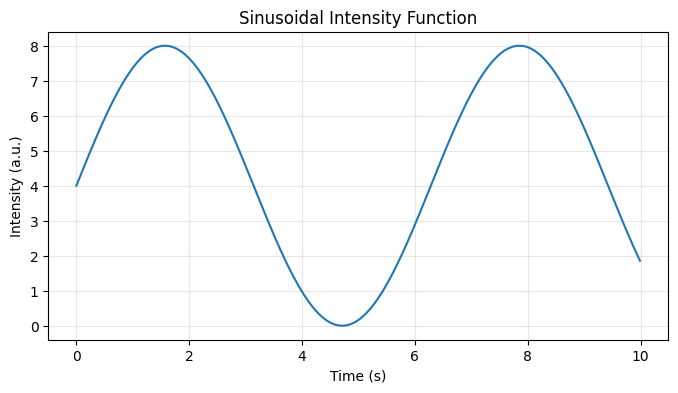

In [2]:
t_max = 10
dt = 0.01
num_steps = int(t_max / dt)
time = np.arange(0, t_max, dt)

# Sinusoidal function
intensity = np.zeros(num_steps)
for i in range(num_steps):
    intensity[i] = 4 * (1 + np.sin(time[i]))

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(time, intensity, label = "Intensity Function")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Sinusoidal Intensity Function")
ax.grid(alpha=0.3)
plt.show()

In [3]:
# Non-homogenous Poisson Process

def generate_spikes(num_steps, dt, intensity):
    spike_probs = np.clip(intensity * dt, 0, 1) # Bernoulli approximation
    spikes = (np.random.rand(num_steps) < spike_probs).astype(np.int8) # 1s or 0s
    return spikes

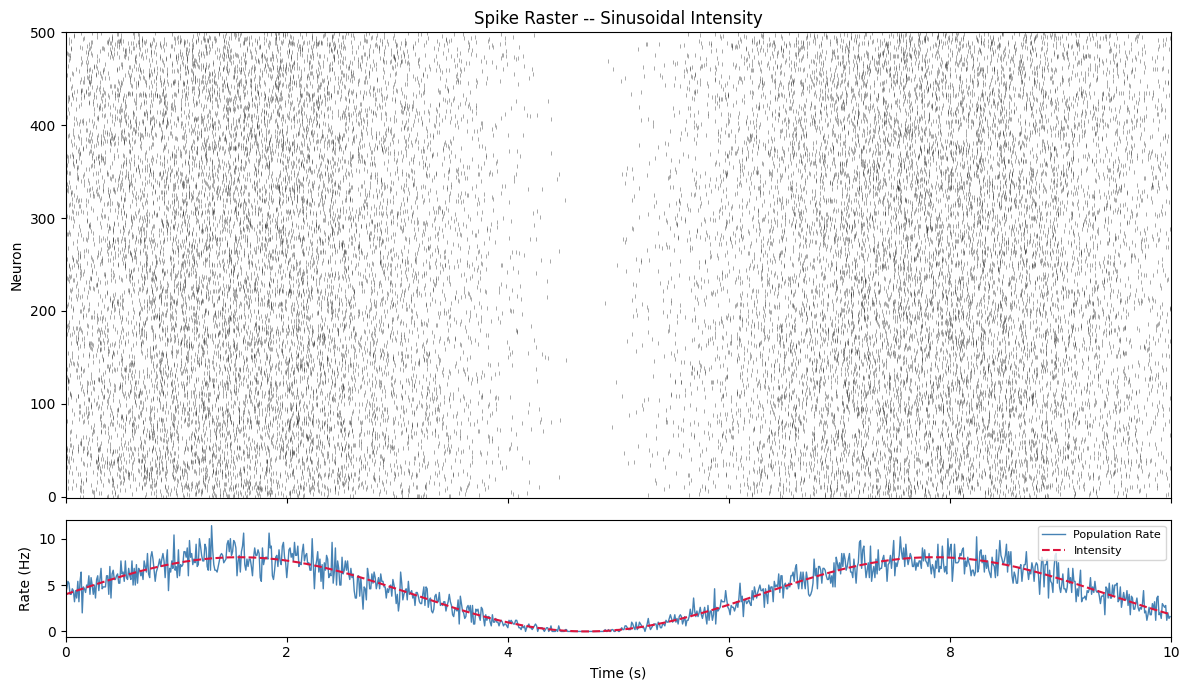

In [4]:
num_neurons = 500
spike_matrix = np.array([
    generate_spikes(num_steps, dt, intensity)
    for _ in range(num_neurons)
])

# Raster plot
fig, axes = plt.subplots(2, 1, figsize = (12,7), gridspec_kw={"height_ratios": [4,1]})

ax = axes[0]
for neuron_idx, spike_train in enumerate(spike_matrix):
    spike_times = time[spike_train == 1]
    ax.scatter(spike_times, np.full_like(spike_times, neuron_idx), marker = "|", s=8, c="black", lw=0.4, alpha = 0.6)

ax.set_ylabel("Neuron")
ax.set_xlim(0, t_max)
ax.set_ylim(-1, num_neurons)
ax.set_title("Spike Raster -- Sinusoidal Intensity")
ax.set_xticklabels([])

# Population firing rate
ax2 = axes[1]
pop_rate = spike_matrix.sum(axis=0) / (num_neurons * dt)
ax2.plot(time, pop_rate, color="steelblue", lw=1, label="Population Rate")
ax2.plot(time, intensity, color="crimson", lw=1.5, linestyle="--", label="Intensity")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Rate (Hz)")
ax2.legend(loc="upper right", fontsize=8)
ax2.set_xlim(0, t_max)

plt.tight_layout()
plt.show()

We can see how the this Poisson process adds randomness to spiking across identical neurons. Now let's do this following eqn (8), which considers long term spiking rates. This is given by
$$
\rho(\infty) \propto \exp\left(-\frac{[\mu^\infty - \theta]^2}{\sigma^2}\right).
$$

This is motivated by the idea that spiking noise makes individual spikes uninformative, but rather longer-term spiking rates carry salient information. Here, for set values of $\mu^\infty$, $\sigma$, and $\theta$, the intensity function becomes constant.

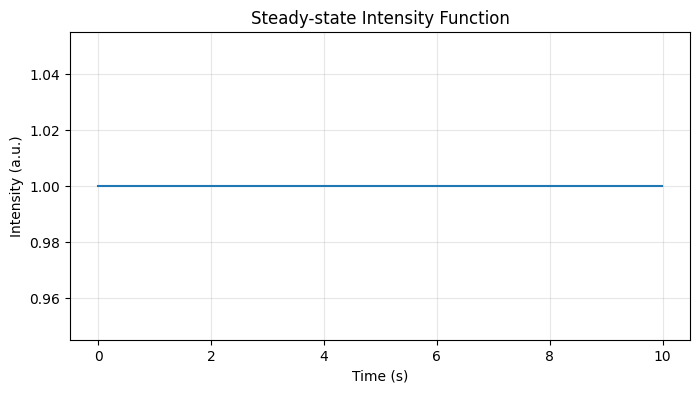

In [5]:
t_max = 10
dt = 0.01
num_steps = int(t_max / dt)
time = np.arange(0, t_max, dt)

# Constant function
intensity = np.zeros(num_steps)
for i in range(num_steps):
    intensity[i] = 1

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(time, intensity, label = "Intensity Function")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Steady-state Intensity Function")
ax.grid(alpha=0.3)
plt.show()

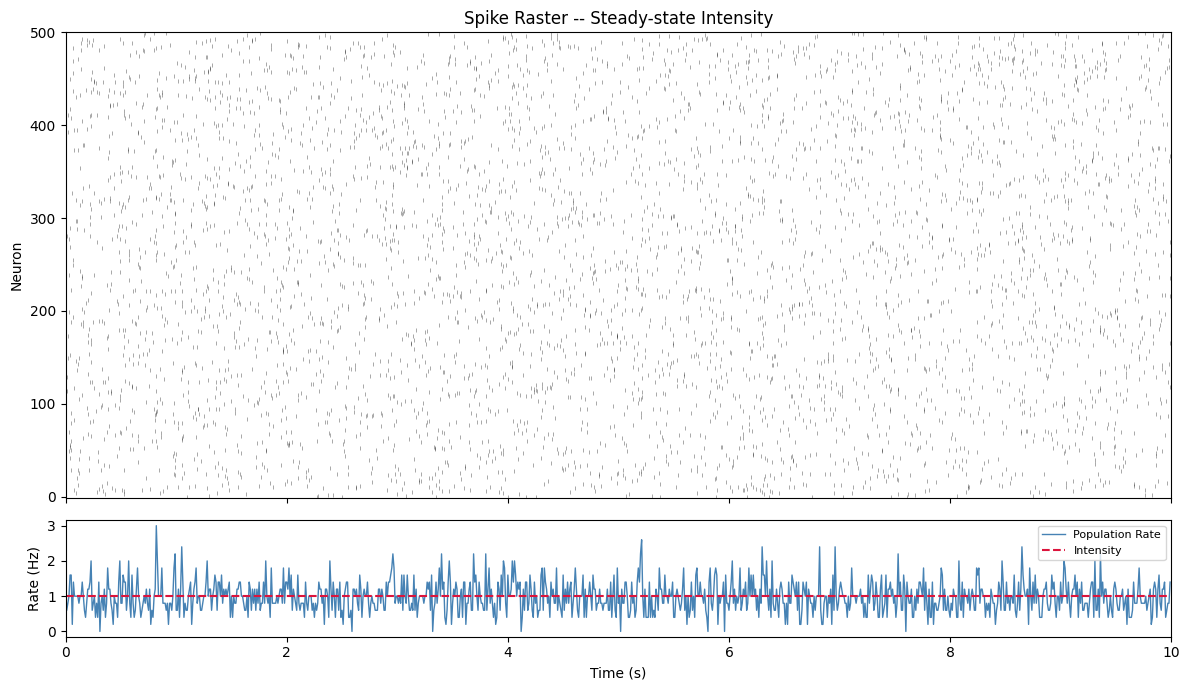

In [6]:
num_neurons = 500
spike_matrix = np.array([
    generate_spikes(num_steps, dt, intensity)
    for _ in range(num_neurons)
])

# Raster plot
fig, axes = plt.subplots(2, 1, figsize = (12,7), gridspec_kw={"height_ratios": [4,1]})

ax = axes[0]
for neuron_idx, spike_train in enumerate(spike_matrix):
    spike_times = time[spike_train == 1]
    ax.scatter(spike_times, np.full_like(spike_times, neuron_idx), marker = "|", s=8, c="black", lw=0.4, alpha = 0.6)

ax.set_ylabel("Neuron")
ax.set_xlim(0, t_max)
ax.set_ylim(-1, num_neurons)
ax.set_title("Spike Raster -- Steady-state Intensity")
ax.set_xticklabels([])

# Population firing rate
ax2 = axes[1]
pop_rate = spike_matrix.sum(axis=0) / (num_neurons * dt)
ax2.plot(time, pop_rate, color="steelblue", lw=1, label="Population Rate")
ax2.plot(time, intensity, color="crimson", lw=1.5, linestyle="--", label="Intensity")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Rate (Hz)")
ax2.legend(loc="upper right", fontsize=8)
ax2.set_xlim(0, t_max)

plt.tight_layout()
plt.show()

### Fano Factor and ISI

The LNP model captures two properties that have been observed in neuron populations. 

- The ratio between the variance and mean of the spike counts is approximately 1,
- The inter-spike interval (time between successive spiking events in one neuron) is approximately exponentially distributed.

In [7]:
# Fano factor

# Mean of spike counts
spk_mean = np.mean(np.sum(spike_matrix, axis=1), axis=0)

# Variance of spike counts
spk_var = np.mean((np.sum(spike_matrix, axis=1) - spk_mean*np.ones((num_neurons,))) ** 2)

print("Fano Factor:", np.round(spk_var / spk_mean, 2))

Fano Factor: 0.96


In [8]:
isis = []

for neuron_idx in range(num_neurons):
    spike_times = time[spike_matrix[neuron_idx] == 1]
    
    # Time differences between consecutive spikes
    neuron_isis = np.diff(spike_times)
    
    isis.extend(neuron_isis)

isis = np.array(isis)

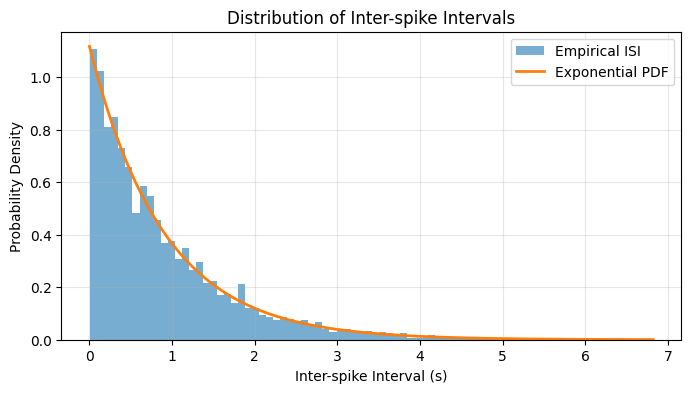

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    isis,
    bins=80,
    density=True,
    alpha=0.6,
    label="Empirical ISI"
)

# Theoretical exponential distribution
rate = 1 / np.mean(isis)

x = np.linspace(0, isis.max(), 500)
exponential_pdf = rate * np.exp(-rate * x)

ax.plot(
    x,
    exponential_pdf,
    lw=2,
    label="Exponential PDF"
)

ax.set_xlabel("Inter-spike Interval (s)")
ax.set_ylabel("Probability Density")
ax.set_title("Distribution of Inter-spike Intervals")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## Conclusions

The Linear-Nonlinear Poisson model is a statistical abstraction of spiking that captures important aspects of real neurons. Although it ignores a mechanistic description of spike generation, the LNP model produces a Fano factor of approximately 1, and an interspike interval distribution that is approximately exponential. These approximately match what is observed in real neurons. To sum up, the LNP model has three parts:

- a **Linear Component**, such as the linear filter taken from the LIF model,
- a **Nonlinearity**, into which the linear component is passed through,
- a **Poisson distribution**, used to define the timing of spike events.

The LNP model is phenomenological as it is not derived from underlying biological mechanisms, but nonetheless serves as a useful description for spiking data.